**Data Source (Data Source):** Istanbul Metropolitan Municipality (IMM)

*Bu proje kapsamında kullanılan veri seti, Istanbul Metropolitan Municipality (IMM) Open Data Portal'ndan elde edilen verilerin birleştirilmesi ve işlenmesiyle oluşturulmuştur.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_recall_curve, average_precision_score)

# Görsel ayarlar
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


In [2]:
# Veri setini okuma
df = pd.read_csv('Istanbul_Final_Analiz_Verisi.csv')

# Özellik seçimi
features = ['İlçe', 'Maks_Sıcaklik_C', 'Toplam_Yağış_mm', 'Maks_Rüzgar_Hızı_kmh', 'average_traffic_index', 'Ay', 'Durum']
target = 'Sağlık_Risk_Durumu'

X = df[features].copy()
y = df[target].copy()

# One-Hot Encoding ve Label Encoding
X_encoded = pd.get_dummies(X, columns=['İlçe', 'Durum'], drop_first=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Eğitim ve Test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Veri seti başarıyla hazırlandı. Toplam örnek sayısı: {len(df)}")
# SMOTE uygulanması (Very High Risk sınıfı için) (Very High Risk sınıfındaki precision sorununu çözmek için)
print("SMOTE Öncesi Sınıf Dağılımı:", np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)
print("SMOTE Sonrası Sınıf Dağılımı:", np.bincount(y_train))


Veri seti başarıyla hazırlandı. Toplam örnek sayısı: 16035
SMOTE Öncesi Sınıf Dağılımı: [6162 5700  908   58]
SMOTE Sonrası Sınıf Dağılımı: [6162 6162 6162 6162]


In [3]:
# Overfitting'i engellemek için budanmış (pruned) model
# Çok Yüksek Risk sınıfının hatasını düşürmek için bu sınıfa ekstra ağırlık (ceza) veriyoruz
vh_risk_idx = list(class_names).index('Çok Yüksek Risk (Tehlikeli)')
custom_weights = {i: 1 for i in range(len(class_names))}
custom_weights[vh_risk_idx] = 5  # Çok yüksek risk için hatayı x5 cezalandır

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight=custom_weights
)

model.fit(X_train_scaled, y_train)

# Tahminler
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)

# Raporlama
print("--- MODEL PERFORMANS ÖZETİ ---")
print(f"Genel Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred) * 100:.2f}")
print(f"F1-Skoru (Weighted): %{f1_score(y_test, y_pred, average='weighted') * 100:.2f}")
print("-" * 30)
print("DETAYLI SINIFLANDIRMA RAPORU:")


--- MODEL PERFORMANS ÖZETİ ---
Genel Doğruluk (Accuracy): %96.32
F1-Skoru (Weighted): %96.40
------------------------------
DETAYLI SINIFLANDIRMA RAPORU:


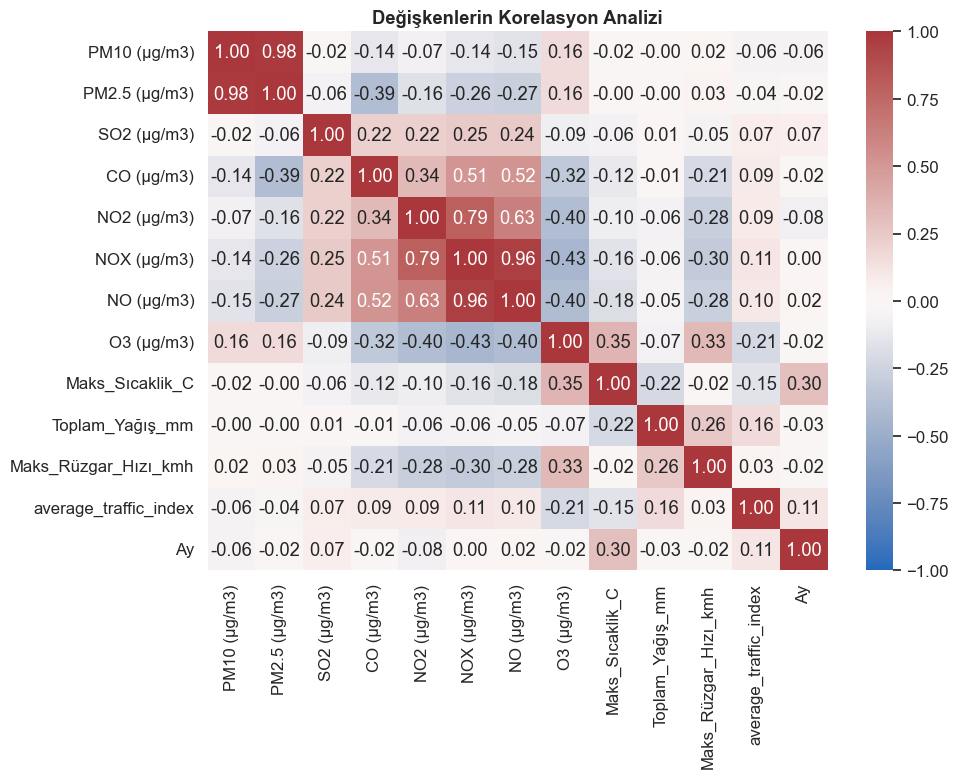

In [4]:
# 1. Korelasyon Matrisi
plt.figure(figsize=(10, 7))
korelasyon = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(korelasyon, annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
plt.title('Değişkenlerin Korelasyon Analizi', fontweight='bold')
plt.show()

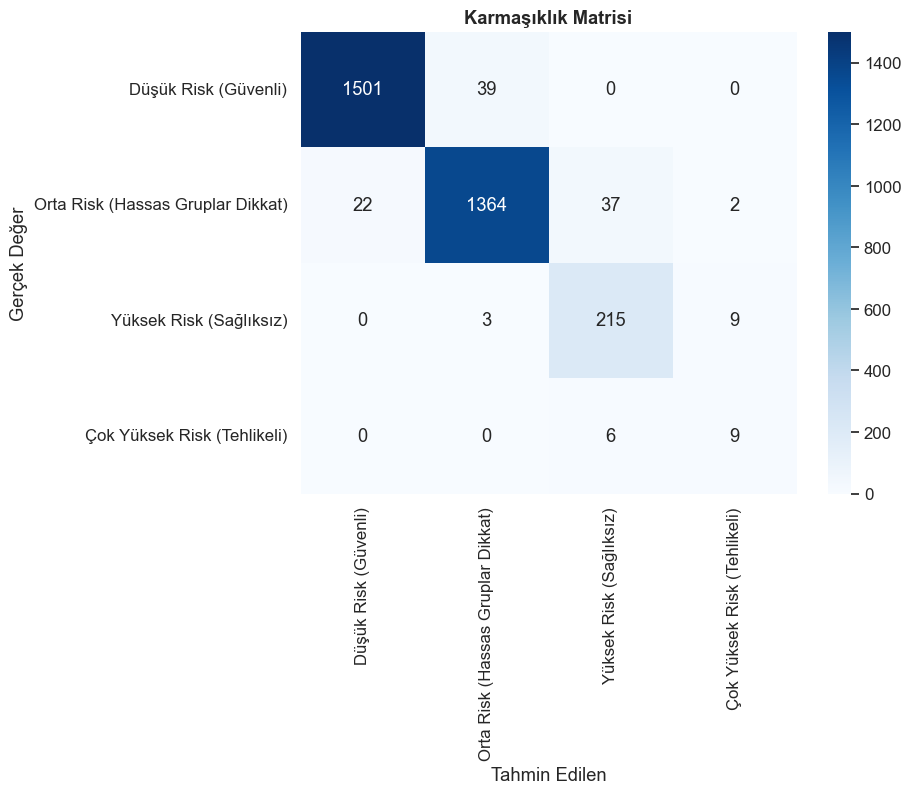

In [5]:
# 2. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Karmaşıklık Matrisi', fontweight='bold')
plt.show()

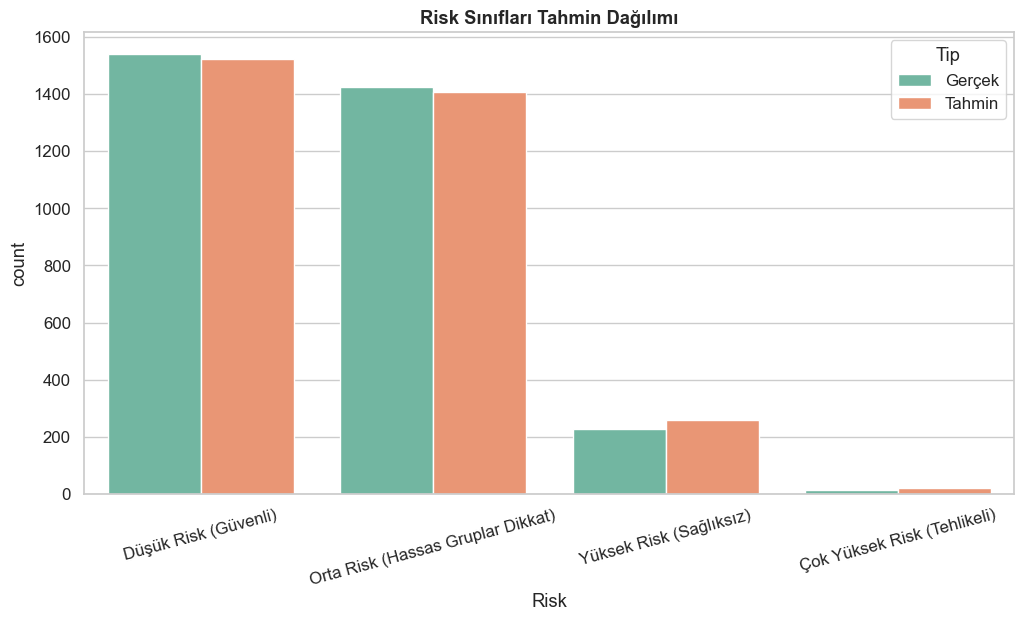

In [6]:
# 3. Gerçek vs Tahmin Dağılımı
res_df = pd.DataFrame({
    'Risk': np.concatenate([le.inverse_transform(y_test), le.inverse_transform(y_pred)]),
    'Tip': ['Gerçek'] * len(y_test) + ['Tahmin'] * len(y_pred)
})
order = res_df[res_df['Tip'] == 'Gerçek']['Risk'].value_counts().index.tolist()

plt.figure(figsize=(12, 6))
sns.countplot(data=res_df, x='Risk', hue='Tip', order=order, palette='Set2')
plt.title('Risk Sınıfları Tahmin Dağılımı', fontweight='bold')
plt.xticks(rotation=15)
plt.show()

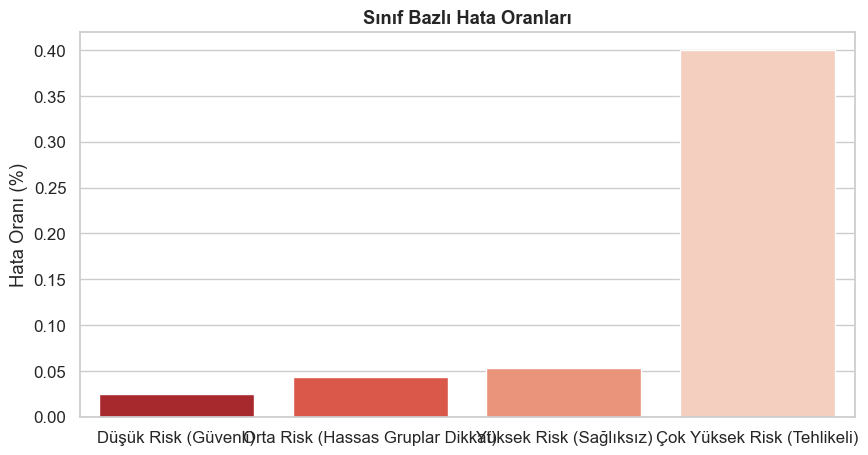

In [7]:
# 4. Hata Oranları
plt.figure(figsize=(10, 5))
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
hata_oranlari = 1 - np.diag(cm_norm)
sns.barplot(x=class_names, y=hata_oranlari, palette='Reds_r')
plt.title('Sınıf Bazlı Hata Oranları', fontweight='bold')
plt.ylabel('Hata Oranı (%)')
plt.show()

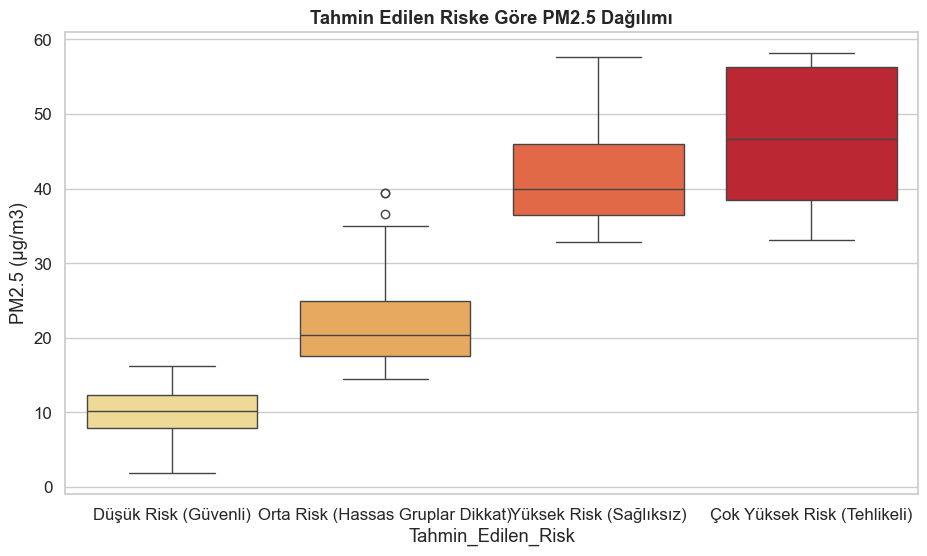

In [8]:
test_data = df.loc[X_test.index].copy()
test_data['Tahmin_Edilen_Risk'] = le.inverse_transform(y_pred)
risk_siralamasi = ['Düşük Risk (Güvenli)', 'Orta Risk (Hassas Gruplar Dikkat)', 'Yüksek Risk (Sağlıksız)', 'Çok Yüksek Risk (Tehlikeli)']
mevcut_riskler = [r for r in risk_siralamasi if r in test_data['Tahmin_Edilen_Risk'].unique()]

# 6. tahmin edilen riske göre pm2.5 dağılımı
plt.figure(figsize=(11, 6))
sns.boxplot(data=test_data, x='Tahmin_Edilen_Risk', y='PM2.5 (µg/m3)', order=mevcut_riskler, palette='YlOrRd')
plt.title('Tahmin Edilen Riske Göre PM2.5 Dağılımı', fontweight='bold')
plt.show()

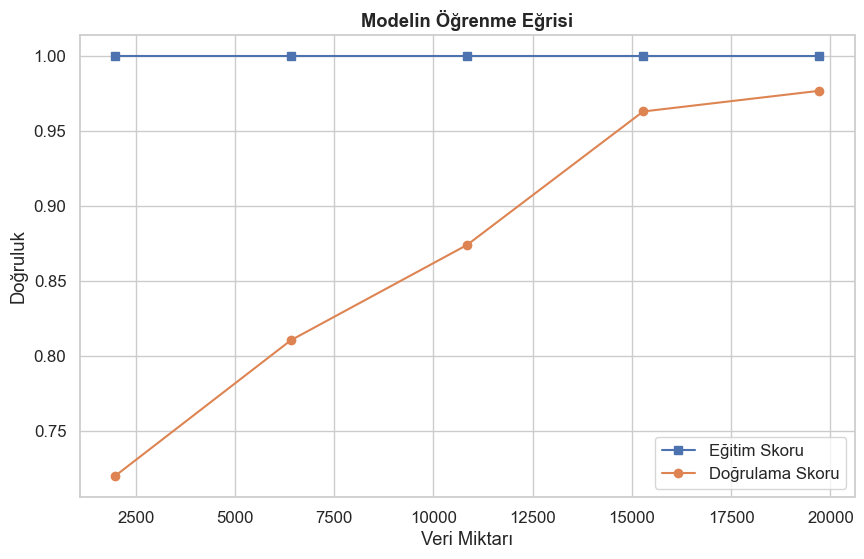

In [9]:
# 7. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(estimator=model, X=X_train_scaled, y=y_train, cv=5)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Eğitim Skoru', marker='s')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Doğrulama Skoru', marker='o')
plt.title('Modelin Öğrenme Eğrisi', fontweight='bold')
plt.xlabel('Veri Miktarı')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

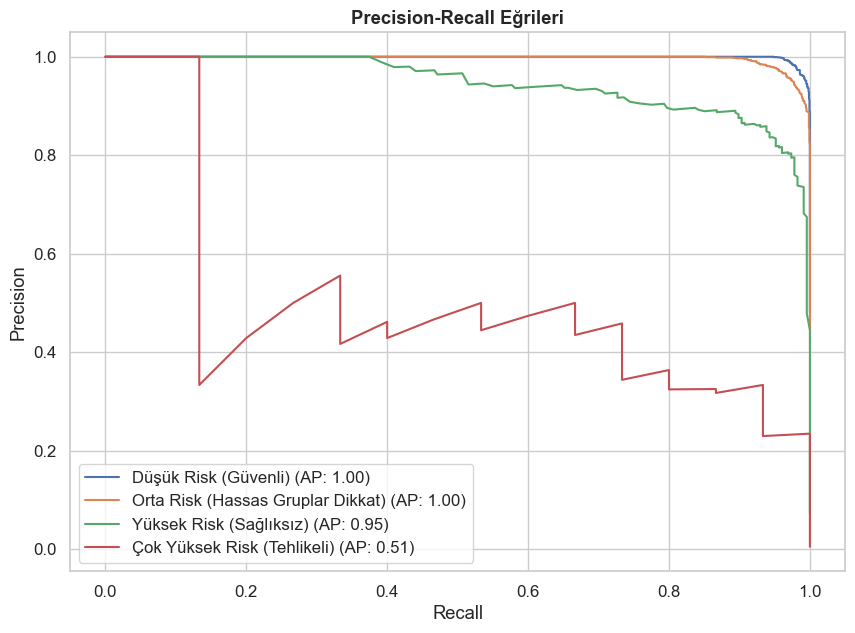

In [10]:
# 8. Precision-Recall
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
plt.figure(figsize=(10, 7))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f'{class_names[i]} (AP: {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Eğrileri', fontweight='bold')
plt.legend()
plt.show()

## XGBoost Modeli ile Karşılaştırma
Ödev geri bildirimlerine istinaden, RandomForest modeline alternatif olarak XGBoost modeli eğitilmiş ve karşılaştırılmıştır.

In [11]:
# XGBoost modelini eğitme
# XGBoost için Çok Yüksek Risk sınıfına ağırlık veriyoruz
vh_risk_idx = list(class_names).index('Çok Yüksek Risk (Tehlikeli)')
sample_weights = np.ones(len(y_train))
sample_weights[y_train == vh_risk_idx] = 5

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=12,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Tahminler
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_prob_xgb = xgb_model.predict_proba(X_test_scaled)

# Raporlama
print("--- XGBOOST MODEL PERFORMANS ÖZETİ ---")
print(f"Genel Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_xgb) * 100:.2f}")
print(f"F1-Skoru (Weighted): %{f1_score(y_test, y_pred_xgb, average='weighted') * 100:.2f}")
print("-" * 30)
print("DETAYLI SINIFLANDIRMA RAPORU (XGBOOST):")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))


--- XGBOOST MODEL PERFORMANS ÖZETİ ---
Genel Doğruluk (Accuracy): %96.73
F1-Skoru (Weighted): %96.82
------------------------------
DETAYLI SINIFLANDIRMA RAPORU (XGBOOST):
                                   precision    recall  f1-score   support

             Düşük Risk (Güvenli)       0.98      0.98      0.98      1540
Orta Risk (Hassas Gruplar Dikkat)       0.98      0.96      0.97      1425
          Yüksek Risk (Sağlıksız)       0.87      0.92      0.90       227
      Çok Yüksek Risk (Tehlikeli)       0.41      0.73      0.52        15

                         accuracy                           0.97      3207
                        macro avg       0.81      0.90      0.84      3207
                     weighted avg       0.97      0.97      0.97      3207



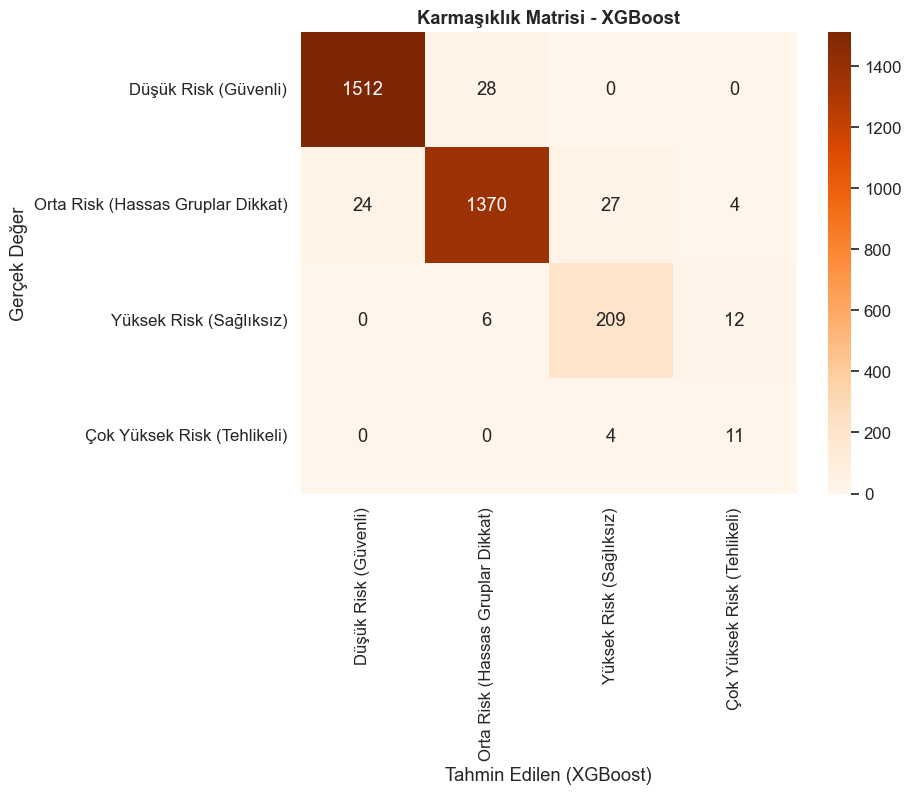

In [12]:
# XGBoost Confusion Matrix
plt.figure(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen (XGBoost)')
plt.ylabel('Gerçek Değer')
plt.title('Karmaşıklık Matrisi - XGBoost', fontweight='bold')
plt.show()


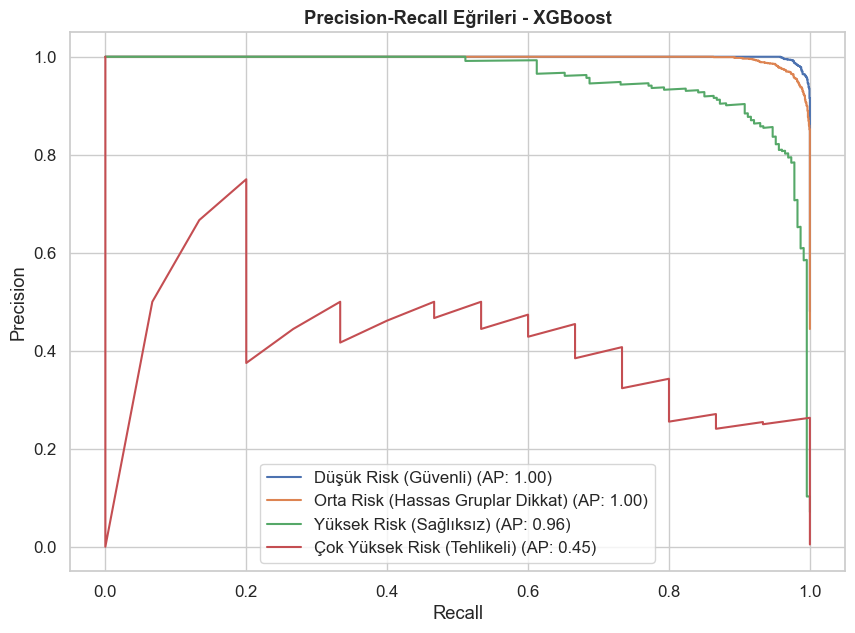

In [13]:
# XGBoost Precision-Recall Eğrisi
plt.figure(figsize=(10, 7))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob_xgb[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_prob_xgb[:, i])
    plt.plot(recall, precision, label=f'{class_names[i]} (AP: {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Eğrileri - XGBoost', fontweight='bold')
plt.legend()
plt.show()


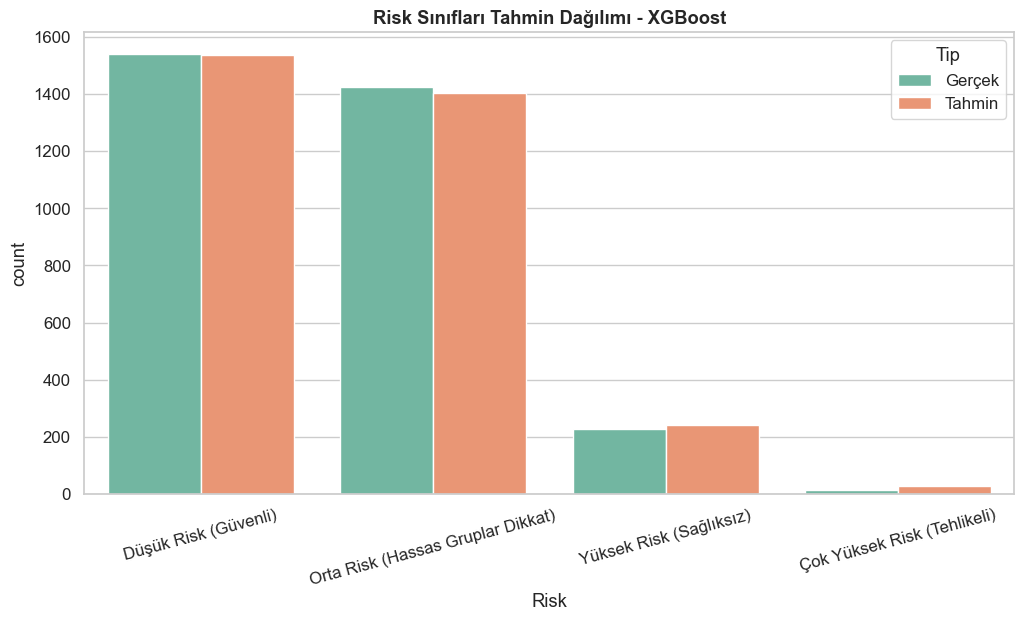

In [14]:
# XGBoost: Gerçek vs Tahmin Dağılımı
res_df_xgb = pd.DataFrame({
    'Risk': np.concatenate([le.inverse_transform(y_test), le.inverse_transform(y_pred_xgb)]),
    'Tip': ['Gerçek'] * len(y_test) + ['Tahmin'] * len(y_pred_xgb)
})
order_xgb = res_df_xgb[res_df_xgb['Tip'] == 'Gerçek']['Risk'].value_counts().index.tolist()

plt.figure(figsize=(12, 6))
sns.countplot(data=res_df_xgb, x='Risk', hue='Tip', order=order_xgb, palette='Set2')
plt.title('Risk Sınıfları Tahmin Dağılımı - XGBoost', fontweight='bold')
plt.xticks(rotation=15)
plt.show()


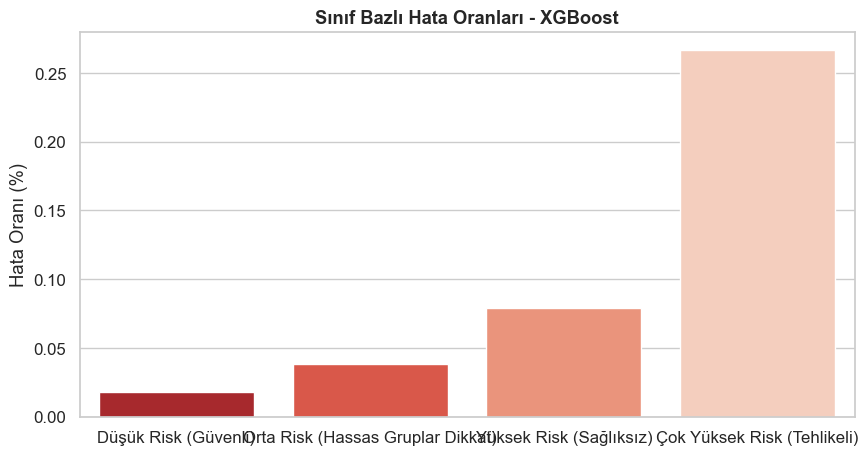

In [15]:
# XGBoost: Sınıf Bazlı Hata Oranları
plt.figure(figsize=(10, 5))
cm_norm_xgb = cm_xgb.astype('float') / (cm_xgb.sum(axis=1)[:, np.newaxis] + 1e-9)
hata_oranlari_xgb = 1 - np.diag(cm_norm_xgb)
sns.barplot(x=class_names, y=hata_oranlari_xgb, palette='Reds_r')
plt.title('Sınıf Bazlı Hata Oranları - XGBoost', fontweight='bold')
plt.ylabel('Hata Oranı (%)')
plt.show()


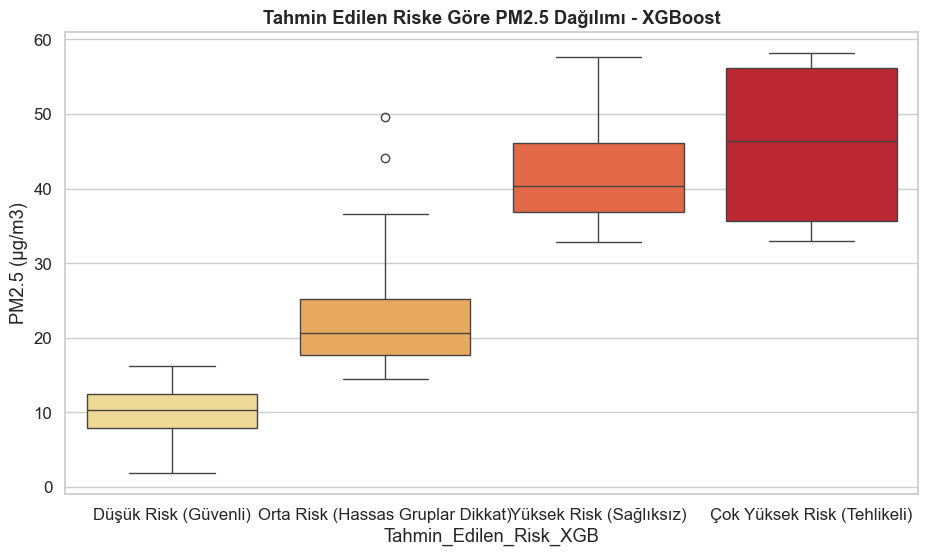

In [16]:
# XGBoost: Tahmin Edilen Riske Göre PM2.5 Dağılımı
test_data_xgb = df.loc[X_test.index].copy()
test_data_xgb['Tahmin_Edilen_Risk_XGB'] = le.inverse_transform(y_pred_xgb)
mevcut_riskler_xgb = [r for r in risk_siralamasi if r in test_data_xgb['Tahmin_Edilen_Risk_XGB'].unique()]

plt.figure(figsize=(11, 6))
sns.boxplot(data=test_data_xgb, x='Tahmin_Edilen_Risk_XGB', y='PM2.5 (µg/m3)', order=mevcut_riskler_xgb, palette='YlOrRd')
plt.title('Tahmin Edilen Riske Göre PM2.5 Dağılımı - XGBoost', fontweight='bold')
plt.show()


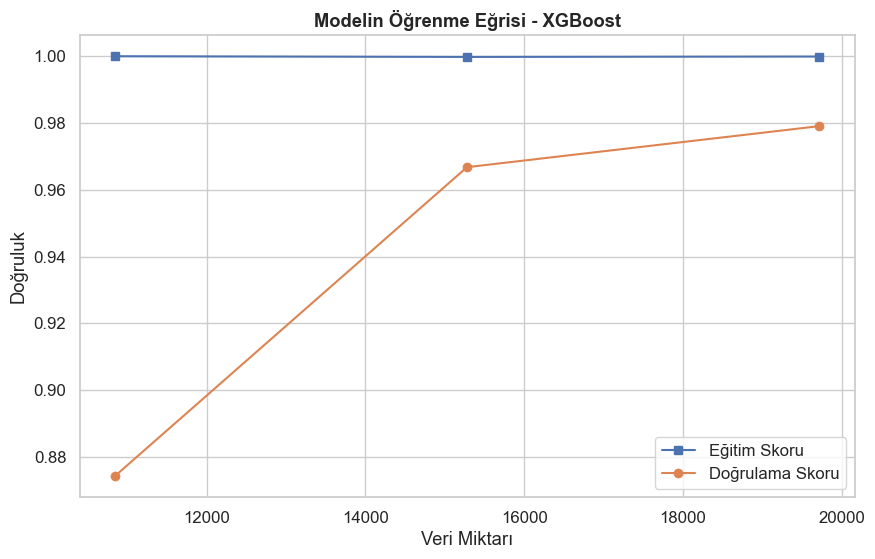

In [17]:
# XGBoost: Learning Curve
train_sizes_xgb, train_scores_xgb, test_scores_xgb = learning_curve(estimator=xgb_model, X=X_train_scaled, y=y_train, cv=5)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_xgb, np.mean(train_scores_xgb, axis=1), label='Eğitim Skoru', marker='s')
plt.plot(train_sizes_xgb, np.mean(test_scores_xgb, axis=1), label='Doğrulama Skoru', marker='o')
plt.title('Modelin Öğrenme Eğrisi - XGBoost', fontweight='bold')
plt.xlabel('Veri Miktarı')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

## Random Forest ve XGBoost Performans Karşılaştırması
Aşağıdaki grafikler iki modelin test seti üzerindeki başarı ve hata oranlarını yan yana kıyaslamak için oluşturulmuştur.

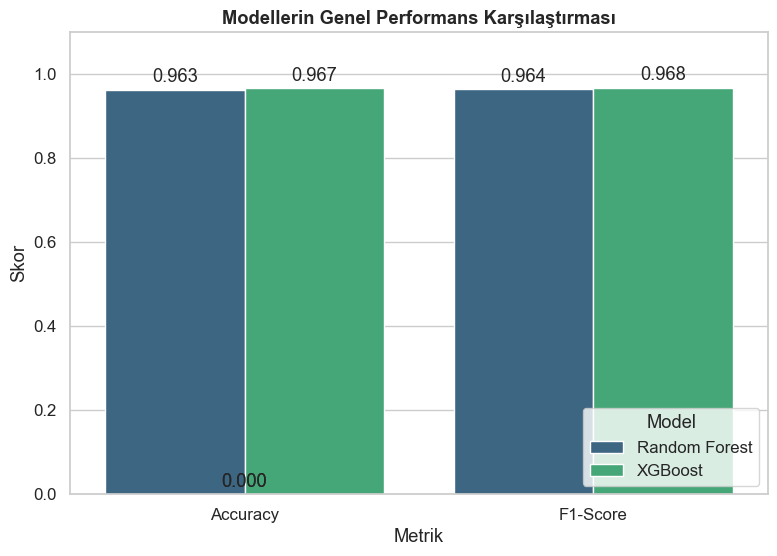

In [18]:
# 1. Genel Performans Karşılaştırması (Accuracy ve F1-Score)
rf_acc = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred, average='weighted')
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

metrics_df = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest', 'XGBoost', 'XGBoost'],
    'Metrik': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Skor': [rf_acc, rf_f1, xgb_acc, xgb_f1]
})

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=metrics_df, x='Metrik', y='Skor', hue='Model', palette='viridis')
plt.title('Modellerin Genel Performans Karşılaştırması', fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Skor')

# Skorları barların üzerine yazdırma
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')
plt.show()


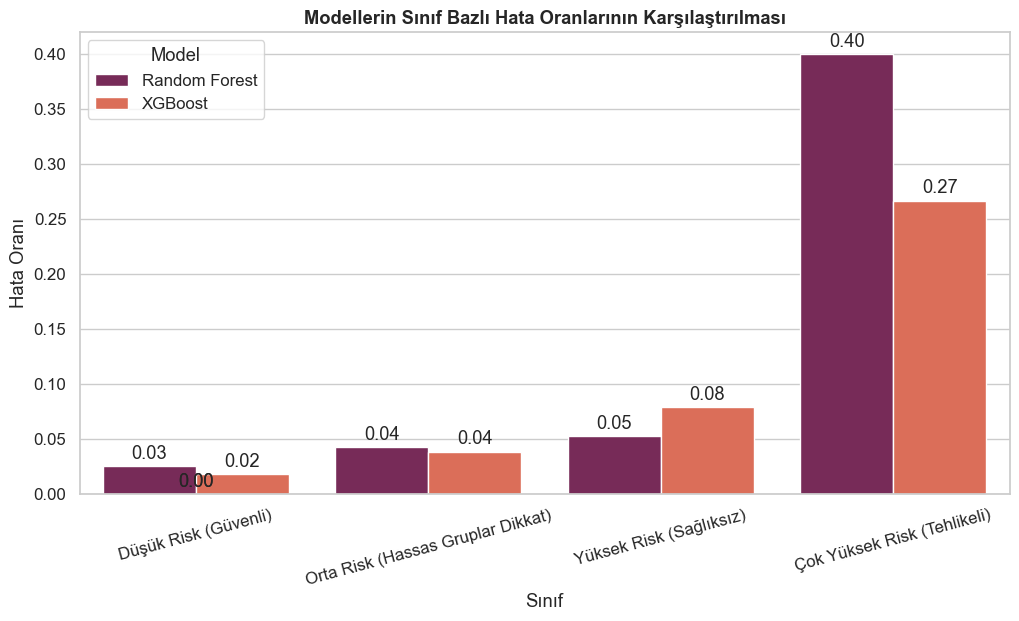

In [19]:
# 2. Sınıf Bazlı Hata Oranı Karşılaştırması
cm_norm_rf = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
hata_rf = 1 - np.diag(cm_norm_rf)

cm_norm_xg = cm_xgb.astype('float') / (cm_xgb.sum(axis=1)[:, np.newaxis] + 1e-9)
hata_xg = 1 - np.diag(cm_norm_xg)

hata_df = pd.DataFrame({
    'Sınıf': list(class_names) * 2,
    'Hata Oranı': np.concatenate([hata_rf, hata_xg]),
    'Model': ['Random Forest']*len(class_names) + ['XGBoost']*len(class_names)
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=hata_df, x='Sınıf', y='Hata Oranı', hue='Model', palette='rocket')
plt.title('Modellerin Sınıf Bazlı Hata Oranlarının Karşılaştırılması', fontweight='bold')
plt.ylabel('Hata Oranı')
plt.xticks(rotation=15)

# Skorları barların üzerine yazdırma
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()
